In [ ]:
import numpy as np
# True binary labels
y_true = np.array([1, 0, 1, 1])
# High-quality predictions
y_pred_good = np.array([0.9, 0.1, 0.8, 0.7])
# Low-quality predictions
y_pred_bad = np.array([0.6, 0.4, 0.55, 0.52])
def mse(y, yhat):
  return np.mean((y - yhat)**2)
def bce(y, yhat):
  epsilon = 1e-9
  yhat = np.clip(yhat, epsilon, 1 - epsilon)
  return -np.mean(y*np.log(yhat) + (1-y)*np.log(1-yhat))
print("Good Prediction - MSE:", mse(y_true, y_pred_good))
print("Good Prediction - BCE:", bce(y_true, y_pred_good))
print("Bad Prediction - MSE:", mse(y_true, y_pred_bad))
print("Bad Prediction - BCE:", bce(y_true, y_pred_bad))

Good Prediction - MSE: 0.0375
Good Prediction - BCE: 0.19763488164214868
Bad Prediction - MSE: 0.18822499999999998
Bad Prediction - BCE: 0.5683536789235665


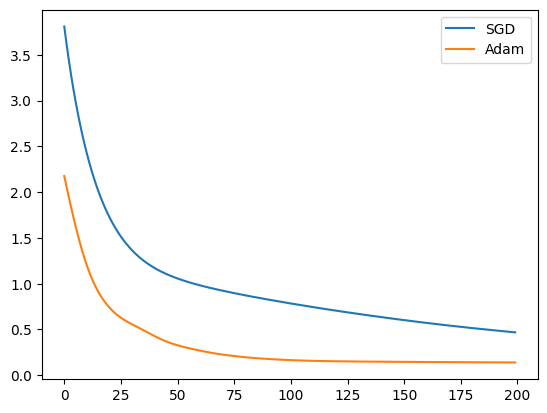

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
X = torch.linspace(-2,2,100).view(-1,1)
y = X**2 + 0.3*torch.randn_like(X)
class SimpleNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear1 = nn.Linear(1,10)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(10,1)
  def forward(self,x):
    x = self.relu(self.linear1(x))
    return self.linear2(x)
def train_model(optimizer_name):
  model = SimpleNet()
  if optimizer_name == "SGD":
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
  elif optimizer_name == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
  loss_fn = nn.MSELoss()
  losses = []
  for epoch in range(200):
    optimizer.zero_grad()
    outputs = model(X)
    loss = loss_fn(outputs, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
  return losses
sgd_loss = train_model("SGD")
adam_loss = train_model("Adam")
plt.plot(sgd_loss, label="SGD")
plt.plot(adam_loss, label="Adam")
plt.legend()
plt.show()

Q3.2.2 With Strong Regularization


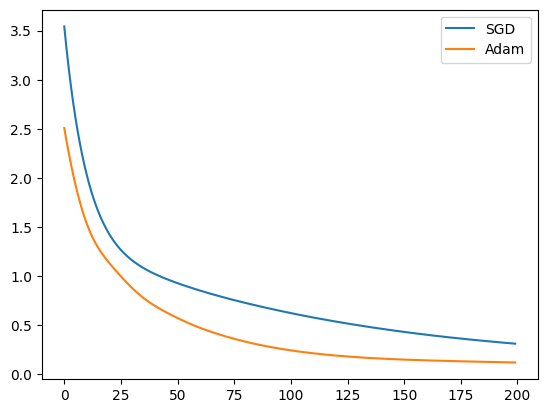

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
X = torch.linspace(-2,2,100).view(-1,1)
y = X**2 + 0.3*torch.randn_like(X)
class SimpleNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear1 = nn.Linear(1,10)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(10,1)
  def forward(self,x):
    x = self.relu(self.linear1(x))
    return self.linear2(x)
def train_model(optimizer_name):
  model = SimpleNet()
  if optimizer_name == "SGD":
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
  elif optimizer_name == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
  loss_fn = nn.MSELoss()
  losses = []
  for epoch in range(200):
    optimizer.zero_grad()
    outputs = model(X)
    loss = loss_fn(outputs, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
  return losses
sgd_loss = train_model("SGD")
adam_loss = train_model("Adam")
plt.plot(sgd_loss, label="SGD")
plt.plot(adam_loss, label="Adam")
plt.legend()
print("Q3.2.2 With Strong Regularization")
plt.show()